In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from inputs_for_plots import *

In [3]:
def prepare_error_dataframe(ols_est, errors_list, column_names):
    """Creates a DataFrame with all error values in a long format."""
    df_list = [pd.DataFrame(np.abs(ols_est), columns=["Biased OLS"])]
    for errors, col_name in zip(errors_list, column_names):
        df_list.append(pd.DataFrame(errors["error"], columns=[col_name]))
    return pd.concat(df_list, axis=1)


## Plot increase in confounding

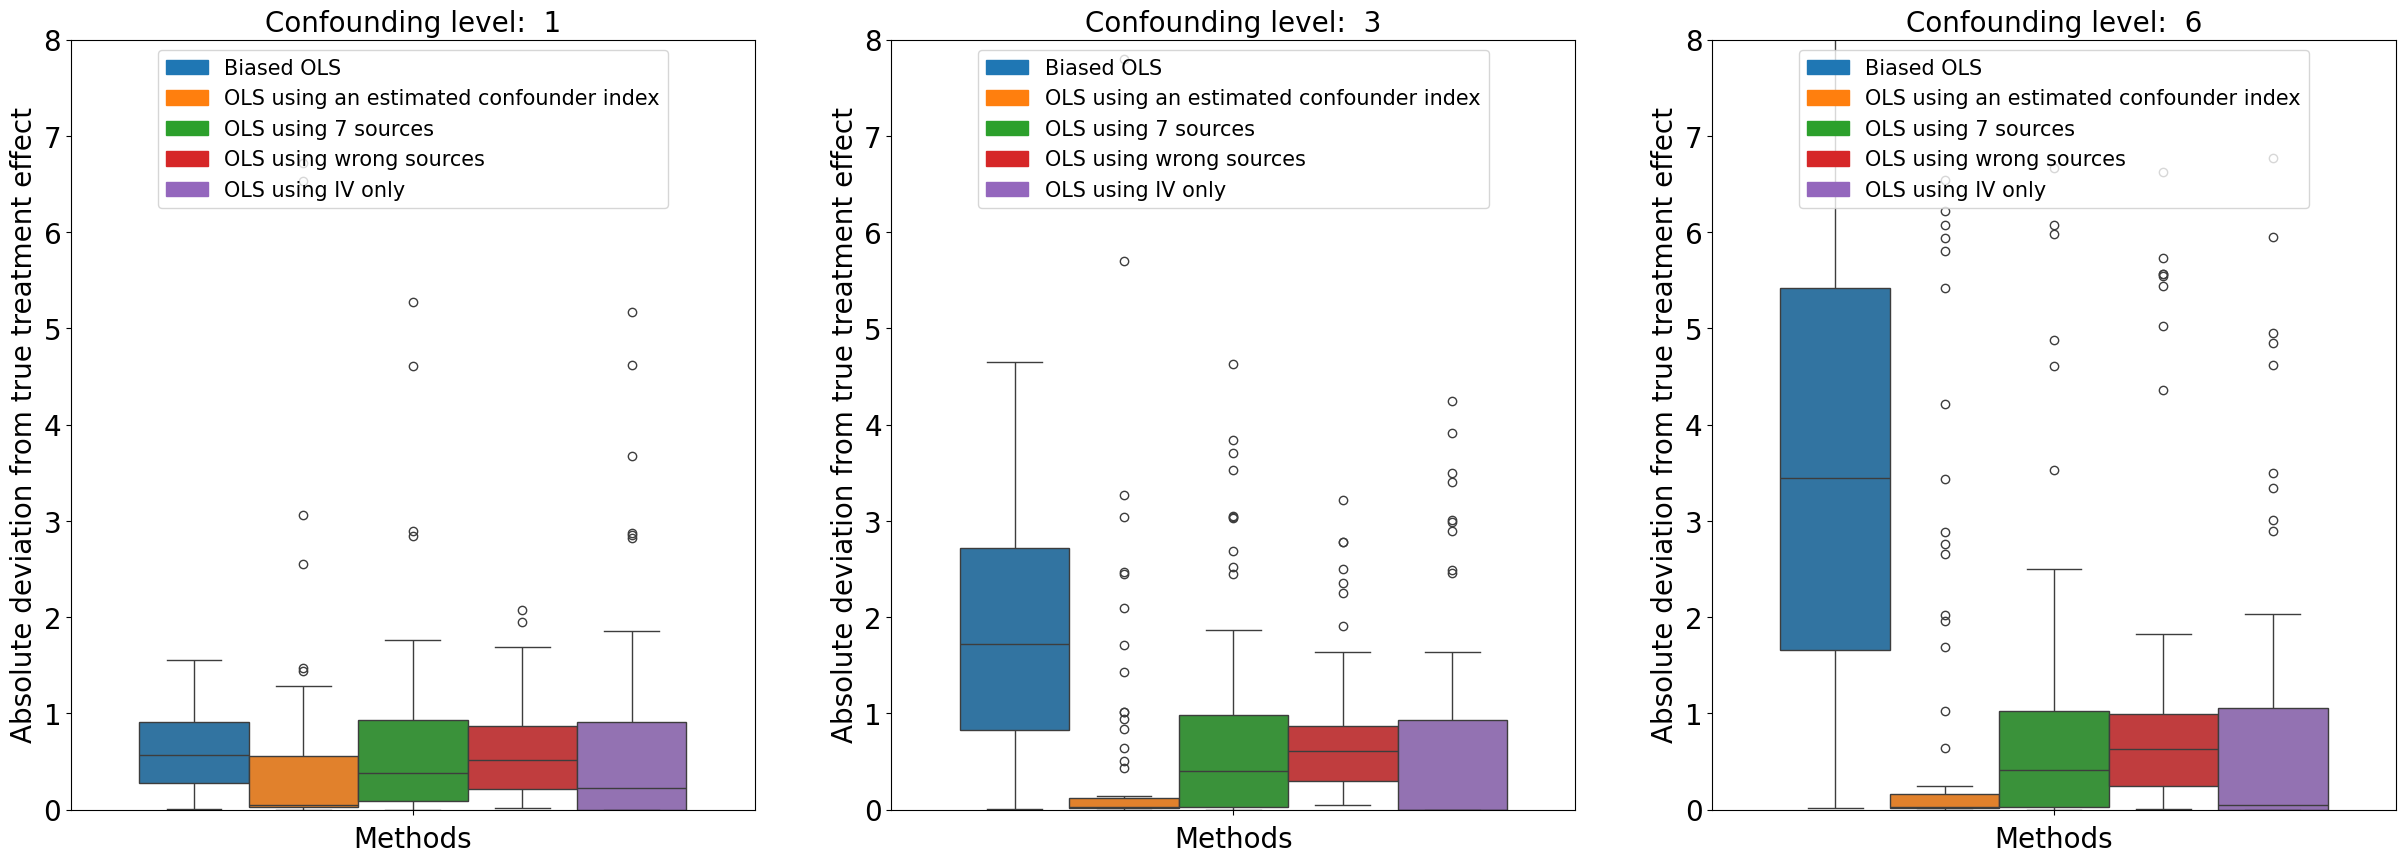

In [4]:
def main_plot(confounder_levels):
    """Generates plots for different confounder levels."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(confounder_levels), figsize=(30, 10))
    
    for i, level in enumerate(confounder_levels):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_confounding_levels/data/", name=f"true_mixing_large_conf_{level}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_confounding_levels/data/", name=f"data_obs_large_conf_{level}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)
        
        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_cn_{level}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_cn_{level}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_cn_{level}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)

        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_cn_{level}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources, errors_nonsense,errors_iv_only ], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[level] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], level, "Confounding level")
    
    plt.show()
    return method_summary

# Example usage
confounder_levels = [1, 3, 6]
method_summary = main_plot(confounder_levels)


In [5]:
print_method_summary(method_summary)

Level 1
       Biased OLS  OLS using an estimated confounder index  \
RMSE     0.688614                                 1.832042   
MAE      0.585996                                 0.612863   
STD      0.687864                                 1.823154   
Cases  100.000000                                87.000000   

       OLS using 7 sources  OLS using wrong sources  OLS using IV only  
RMSE              1.565732                 0.731443           1.662679  
MAE               0.753034                 0.592085           0.755280  
STD               1.565423                 0.708569           1.662184  
Cases            97.000000                89.000000          90.000000  
Level 3
       Biased OLS  OLS using an estimated confounder index  \
RMSE     2.060265                                 5.535587   
MAE      1.753669                                 1.565944   
STD      2.057837                                 5.495530   
Cases  100.000000                                87.000000  

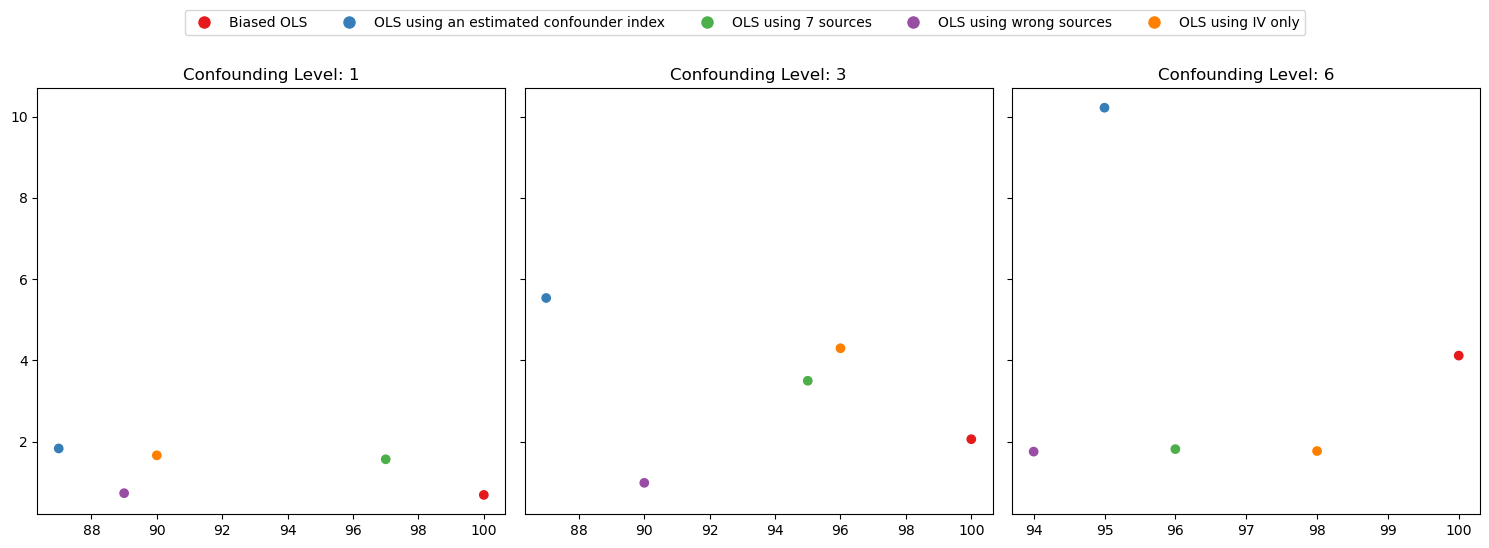

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Define the color palette
palette = sns.color_palette("Set1", 5)

# Iterate over the confounding levels and plot the data
for i, level in enumerate(confounder_levels):
    methods = method_summary[level]["cases"].keys()
    cases = method_summary[level]["cases"].values()
    rmse = method_summary[level]["rmse"]

    # Scatter plot
    ax[i].scatter(cases, rmse, c=palette, label=methods)
    
    # Set the title with confounding level
    ax[i].set_title(f"Confounding Level: {level}")

# Create the legend handles
legend_labels = list(methods)
legend_colors = palette[:len(legend_labels)]
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in legend_colors]

# Add the legend above all subplots
fig.legend(handles, legend_labels, loc='upper center', ncol=len(legend_labels), bbox_to_anchor=(0.5, 1.1))
plt.tight_layout()
# Show the plot
plt.show()

## Plot different number of covariates

FileNotFoundError: [Errno 2] No such file or directory: '../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_number_of_covs_3.csv'

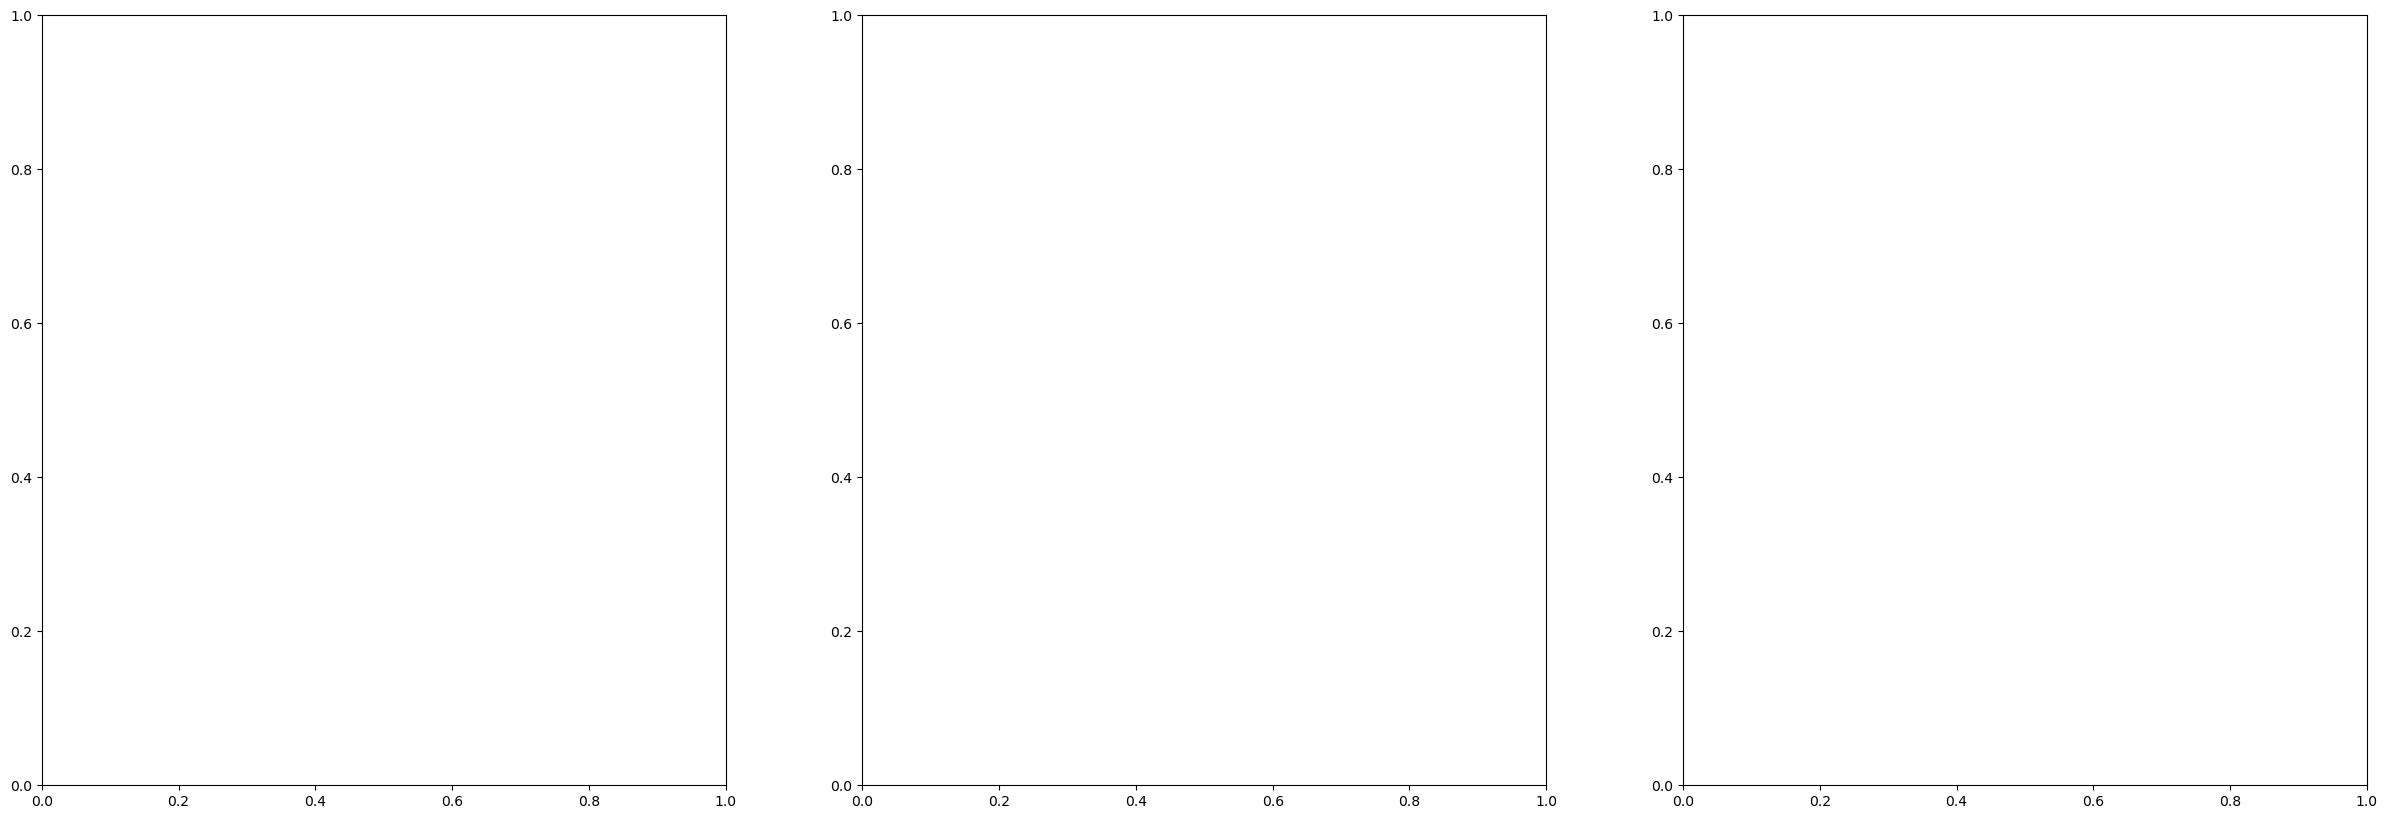

In [9]:
def main_plot(number_of_covariates):
    """Generates plots for different number of covariates."""
    method_summary = {}
    fig, axes = plt.subplots(1, len(number_of_covariates), figsize=(30, 10))
    
    for i, covs in enumerate(number_of_covariates):
        rmse, mae, std = [], [], []
        true_treatment_effect = get_true_treatment_effect(path=f"data_generation/different_numbers_of_covariates/data/", name=f"true_mixing_covs_{covs}_")
        ols_est = calculate_ols_estimate(path=f"data_generation/different_numbers_of_covariates/data/", name=f"data_obs_covs_{covs}_")
        ols_est = np.array(ols_est) - np.array(true_treatment_effect)
        gather_statistics({"RMSE": np.sqrt(np.mean(np.array(ols_est)**2)), "MAE": np.mean(np.abs(ols_est)), "STD": np.std(ols_est)}, rmse, mae, std)


        errors_confounder = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_confounder_source_number_of_covs_{covs}.csv", "estimated_treatment_using_confounder_source", "true_treatment_effect")
        gather_statistics(errors_confounder, rmse, mae, std)
        
        errors_7_sources = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_number_of_covs_{covs}.csv", "estimated_treatment_on_sources", "true_treatment_effect")
        gather_statistics(errors_7_sources, rmse, mae, std)
        
        errors_nonsense = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_7_sources_nonsense_number_of_covs_{covs}.csv", "mistaken_scheme", "true_treatment_effect")
        gather_statistics(errors_nonsense, rmse, mae, std)
        
        errors_iv_only = load_and_calculate_errors(f"../treatment_effect_estimation/treatment_effect_estimations/true_sources_iv_only_number_of_covs_{covs}.csv", "iv_only_effect", "true_treatment_effect")
        gather_statistics(errors_iv_only, rmse, mae, std)

        
        
        err = prepare_error_dataframe(ols_est, [errors_confounder, errors_7_sources, errors_nonsense, errors_iv_only], ["OLS using an estimated confounder index", "OLS using 7 sources", "OLS using wrong sources", "OLS using IV only"])
        
        cases = {col: 100 - err[col].isna().sum() for col in err.columns}
        method_summary[covs] =  {"cases": cases,"rmse": rmse, "mae": mae, "std": std}
        plot_errors(err, rmse, mae, std, axes[i], covs, "Number of covariates")
    
    plt.show()
    return method_summary

# Example usage
number_of_covariates = [3, 6, 9]
method_summary = main_plot(number_of_covariates)


